## Free Throw Model — Cross‑Session Evaluation & Calibration

### Prerequisites: 
* Run feature engineering scripts (extract_phase_features.py and prepare_phase_dataset.py) to get features. 

### Machine Learning Pipeline:
- #### **Step 1** Split data between training/validation and testing
    - Right now I’m using 80% of the data for training/validation and 20% for testing.
- #### **Step 2** Hyperparemeter Tuning 
    - k fold cross validation and a grid search to find the hyperparameters for each model that optimize f1 score
- #### **Step 3** Calibration/Thresholding on best CV models
    - two **calibration** methods:
        - sigmoid
        - isotonic 
    - two **thresholding** methods: 
        - highest F1 score possible
        - F1 score measured at the threshold where precision is constrained to 70%
- #### **Step 4** Final Training and Testing
    - train best performing models on all training data
    - plot confusion matrices, reliability curves, and precision recall curves 
- #### **Step 5** Diagnostics of Final Models
    - Test the model on the 20% testing data and see how it does on data that it has not seen before
- #### **Step 6** Feature Pruning
    - From permutation Importance

# TODO 
* Better Analysis/Interpretation
* Better Model Performance: (PR Curves, ROC curves, calibration curves)
* Feature Importance: coefficients (LogReg), impurity (RF/GB), SHAP/Permutation importances
* Error analysis: confusion matrix, misclassified samples.
* Save everything: model weights, plots, tables, config
* Make yaml config files control all configuration in this script 

In [1]:
# =================================================
# Create unique experiment directory 
# =================================================

from datetime import datetime
import re
from pathlib import Path
import yaml

PROJECT_ROOT = Path().resolve().parent # go up one level

# Load feature config
feature_cfg_path = PROJECT_ROOT / "feature_config.yaml"
with open(feature_cfg_path, "r") as f:
    feature_config = yaml.safe_load(f)

FEATURE_VERSION = feature_config["feature_version"]
MODEL_TYPE = feature_config["model_type"]   # "summary_stats" or "time_series"

# --- makes label for the experiment ---
def start_run(label: str = "baseline") -> Path:
    ts = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
    
    # put MODEL_TYPE under experiments
    root = PROJECT_ROOT / "experiments" / MODEL_TYPE
    root.mkdir(parents=True, exist_ok=True)
    
    existing = sorted(root.glob(f"{ts}_run-*_{label}"))
    idx = 1
    if existing:
        m = re.search(r"_run-(\d{3})_", existing[-1].name)
        idx = (int(m.group(1)) + 1) if m else 1
    
    rd = root / f"{ts}_run-{idx:03d}_{label}"
    rd.mkdir(parents=True, exist_ok=True)
    print(f"[INFO] Run directory: {rd}")
    return rd

run_dir = start_run("baseline")

[INFO] Run directory: /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-27_12-21-56_run-001_baseline


In [ ]:

# =================================================
# Step 0: Import Libraries and Create Models
# =================================================

from __future__ import annotations
from pathlib import Path
from joblib import dump, load

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import json
import re

# --- sklearn ---
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, f1_score, average_precision_score, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score as _f1_for_perm
from sklearn.model_selection import GridSearchCV, StratifiedKFold, GroupKFold
from sklearn.metrics import make_scorer, f1_score, average_precision_score, brier_score_loss

from sklearn.metrics import (
    precision_recall_fscore_support, average_precision_score,
    roc_auc_score, brier_score_loss
)
from sklearn.metrics import (
    precision_score, recall_score, f1_score, 
    average_precision_score, roc_auc_score
)
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score, brier_score_loss,
    confusion_matrix
)

# --- Plotting Util (saves CM, PR, calibration) ---
from plots import save_all_eval_figures

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    brier_score_loss, confusion_matrix
)

# --- Load Project Config ---
project_cfg_path = PROJECT_ROOT / "project_config.yaml"
with open(project_cfg_path, "r") as f:
    project_config = yaml.safe_load(f)

ATHLETE = project_config["athlete"]
SESSION = project_config["session"]


POS_LABEL = 0 # set to 1 for 'make', 0 for 'miss'

# --- Load Feature Config ---
feature_cfg_path = PROJECT_ROOT / "feature_config.yaml"
with open(feature_cfg_path, "r") as f:
    feature_config = yaml.safe_load(f)

FEATURE_VERSION = feature_config["feature_version"] # version of feature data set 
MODEL_TYPE = feature_config["model_type"] # summary_stats or time_series

# --- Paths and Directories ---
DATA_ROOT = PROJECT_ROOT / "data" / ATHLETE

SESSIONS = {
    "session_01": DATA_ROOT / "session_01" / "analysis" / "datasets" / "features" / MODEL_TYPE / FEATURE_VERSION,
    "session_02": DATA_ROOT / "session_02" / "analysis" / "datasets" / "features" / MODEL_TYPE / FEATURE_VERSION,
    "session_03": DATA_ROOT / "session_03" / "analysis" / "datasets" / "features" / MODEL_TYPE / FEATURE_VERSION,
    "session_04": DATA_ROOT / "session_04" / "analysis" / "datasets" / "features" / MODEL_TYPE / FEATURE_VERSION
    # add more sessions here...
}

In [48]:
# =================================================
# Step 1: Split data into train/validation and test
# =================================================

TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train_list, X_test_list = [], []
y_train_list, y_test_list = [], []
session_train_list, session_test_list = [], []

for session_name, base in SESSIONS.items():
    # Load
    X = pd.read_csv(base / "X.csv")
    y = pd.read_csv(base / "y.csv").squeeze("columns").astype(int)

    # Stratify class proportions based on y (makes/misses)
    strat = y if y.nunique() > 1 else None
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=strat 
    )

    # Store with session labels
    X_train_list.append(X_tr) 
    X_test_list.append(X_te)
    y_train_list.append(y_tr)
    y_test_list.append(y_te)
    session_train_list.extend([session_name] * len(y_tr))
    session_test_list.extend([session_name] * len(y_te))

# Concatenate everything
X_train = pd.concat(X_train_list, ignore_index=True)
X_test  = pd.concat(X_test_list, ignore_index=True)
y_train = pd.concat(y_train_list, ignore_index=True)
y_test  = pd.concat(y_test_list, ignore_index=True)
session_train = pd.Series(session_train_list, name="session")
session_test  = pd.Series(session_test_list, name="session")

print("[INFO] Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("\n[TRAIN counts]")
print(pd.crosstab(session_train, y_train))
print("\n[TEST counts]")
print(pd.crosstab(session_test, y_test))

[INFO] Train shape: (399, 133) Test shape: (101, 133)

[TRAIN counts]
_label       0    1
session            
session_01  10    5
session_02  27   52
session_03  53   92
session_04  50  110

[TEST counts]
_label       0   1
session           
session_01   3   1
session_02   7  13
session_03  14  23
session_04  13  27


In [ ]:
# =================================================
# A. Pre-Modeling EDA
# =================================================
import matplotlib.pyplot as plt
import seaborn as sns

# --- Class balance ---
plt.figure(figsize=(5,4))
y_train.value_counts().plot(kind="bar", color=["#66c2a5", "#fc8d62"])
plt.title("Class Balance (Train)")
plt.xlabel("Label (0=Make, 1=Miss)")
plt.ylabel("Count")
plt.show()

# --- Feature distributions ---
num_cols = X_train.columns[:10]  # sample first 10 to avoid clutter
fig, axes = plt.subplots(len(num_cols)//2, 2, figsize=(12, 20))
for ax, col in zip(axes.flatten(), num_cols):
    sns.kdeplot(data=X_train, x=col, hue=y_train, common_norm=False, ax=ax)
    ax.set_title(f"Distribution of {col} by Label")
plt.tight_layout()
plt.show()

# --- Correlation heatmap ---
plt.figure(figsize=(12,10))
corr = X_train.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


In [63]:
# =================================================
# Step 2: Tune model hyperparameters
# =================================================

# --- score extractors that respect POS_LABEL and work with Pipelines ---

def _classes_of(est):
    if hasattr(est, "classes_"):
        return est.classes_
    if isinstance(est, Pipeline):
        return _classes_of(est.steps[-1][1])
    if hasattr(est, "best_estimator_"):
        return _classes_of(est.best_estimator_)
    raise AttributeError("Could not find classes_ on estimator/pipeline.")

def get_pos_scores(est, X, pos_label):
    # Prefer predict_proba; fallback to decision_function
    if hasattr(est, "predict_proba"):
        proba = est.predict_proba(X)
        classes = list(_classes_of(est))
        idx = classes.index(pos_label)
        return proba[:, idx]
    if hasattr(est, "decision_function"):
        df = est.decision_function(X)
        classes = list(_classes_of(est))
        if df.ndim == 1:
            return df if pos_label == classes[1] else -df
        idx = classes.index(pos_label)
        return df[:, idx]
    raise AttributeError("Estimator has neither predict_proba nor decision_function.")

def ap_pos_scorer(est, X, y):
    s = get_pos_scores(est, X, POS_LABEL)
    return average_precision_score(y, s, pos_label=POS_LABEL)

def roc_pos_scorer(est, X, y):
    s = get_pos_scores(est, X, POS_LABEL)
    return roc_auc_score(y, s)

# MODELS dict: define the 7 classifiers you want to compare
# - class_weight="balanced" helps when dataset is imbalanced 
MODELS = {
    "LogisticRegression": LogisticRegression(
        max_iter=2000,      # allow more iterations to ensure convergence
        solver="lbfgs",     # recommended solver for small/medium datasets
        class_weight="balanced"
    ),
    "KNN": KNeighborsClassifier(),  # needs scaling, handled in pipeline
    "DecisionTree": DecisionTreeClassifier(
        random_state=42,    # reproducibility
        class_weight="balanced"
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,   # number of trees
        random_state=42,
        class_weight="balanced"
    ),
    "GradientBoosting": GradientBoostingClassifier(
        random_state=42
        # no class_weight support here; handle imbalance via sample_weight if needed
    ),
    "SVM": SVC(
        kernel="rbf",       # nonlinear kernel
        probability=True,   # enables predict_proba (slower but needed for metrics like AP/Brier/LogLoss)
        class_weight="balanced",
        random_state=42
    ),
    "LinearSVC": LinearSVC(
        C=1.0,
        max_iter=10000,     # iterations; may need increasing if convergence warnings appear
        tol=1e-3,           # tolerance for stopping criterion
        class_weight="balanced"
    ),
}

# =================================================
# Pipelines: wrap each model in preprocessing steps if needed
# =================================================
# - Models like LogisticRegression, KNN, SVM, LinearSVC are sensitive to feature scales → add StandardScaler
# - Tree-based models (DecisionTree, RF, GB) are scale-invariant → no scaler
pipelines = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MODELS["LogisticRegression"])
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MODELS["KNN"])
    ]),
    "DecisionTree": Pipeline([
        ("clf", MODELS["DecisionTree"])
    ]),
    "RandomForest": Pipeline([
        ("clf", MODELS["RandomForest"])
    ]),
    "GradientBoosting": Pipeline([
        ("clf", MODELS["GradientBoosting"])
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MODELS["SVM"])
    ]),
    "LinearSVC": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MODELS["LinearSVC"])
    ]),
}

# =================================================
# Hyperparameter grids for each model
# =================================================
# These define the search space for GridSearchCV.
# Adjust ranges based on dataset size
# Currently set for ~ 500 clips 

n_samples, n_features = X_train.shape
LINSVC_DUAL = (n_features > n_samples)  # True if p>n; False if n>p

param_grids = {
    "LogisticRegression": {
        "clf__C": [0.1, 1.0, 10.0],
        "clf__penalty": ["l2"],
        "clf__solver": ["lbfgs"],
    },

    "KNN": {
        "clf__n_neighbors": [3, 5, 7, 11],
        "clf__weights": ["uniform", "distance"],
        "clf__p": [1, 2],                
        "clf__leaf_size": [15, 30],  
    },

    "DecisionTree": {
        "clf__max_depth": [None, 4, 8],
        "clf__min_samples_split": [2, 5],
        "clf__min_samples_leaf": [1, 5, 10],
        "clf__max_features": [None, "sqrt"],
    },

    "RandomForest": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [None, 4, 8],
        "clf__min_samples_split": [2, 5],
        "clf__min_samples_leaf": [1, 5],
        "clf__max_features": ["sqrt", "log2"],
    },

    "GradientBoosting": {
        "clf__n_estimators": [50, 100, 200],
        "clf__learning_rate": [0.05, 0.1],
        "clf__max_depth": [2, 3],
        "clf__subsample": [0.7, 1.0],    
    },

    "SVM": {
        "clf__C": [0.3, 1.0, 3.0],
        "clf__gamma": ["scale"],
    },

    "LinearSVC": {
        "clf__C": [0.1, 1.0, 3.0],
        "clf__loss": ["squared_hinge"],
        "clf__tol": [1e-3],
        "clf__max_iter": [20000, 50000],
        "clf__dual": [LINSVC_DUAL],
    },
}

# =================================================
# CV splitter and scoring metrics
# =================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # StratifiedKFold preserves class distribution across folds.
# TODO maybe use GroupKFold in the future

scoring = {
    "f1_pos": make_scorer(f1_score, pos_label=POS_LABEL),   # uses est.predict() internally
    "ap_pos": ap_pos_scorer,                                # uses scores; no needs_threshold kw
    "roc":    roc_pos_scorer,                               # uses scores
}


# =================================================
# Grid Search loop
# =================================================
leaderboard_rows = []
best_models = {}

for name, pipe in pipelines.items():
    print(f"\n=== Tuning {name} ===")
    
    grid = GridSearchCV(
        estimator=pipe,              # the pipeline to tune
        param_grid=param_grids[name],# hyperparameter search space
        cv=cv,                       # cross-validation strategy
        scoring=scoring,             # all metrics in dict
        refit="f1_pos",              # choose final model based on this metric
        n_jobs=-1,                   # use all CPUs for speed
        verbose=0,                   # 0 = silent, >0 = more logging per fit
        return_train_score=False,     # don’t store train scores (saves memory)
        error_score=np.nan
    )
    grid.fit(X_train, y_train)

    best_models[name] = grid.best_estimator_  # store the best-tuned pipeline

    # --- derive precision/recall for POS_LABEL from CV predictions ---
    y_pred = grid.best_estimator_.predict(X_train)
    prec = precision_score(y_train, y_pred, pos_label=POS_LABEL, zero_division=0)
    rec  = recall_score(y_train, y_pred, pos_label=POS_LABEL, zero_division=0)

    # Extract leaderboard info
    row = {
        "model": name,
        "best_params": grid.best_params_,
        "cv_f1":  grid.cv_results_["mean_test_f1_pos"][grid.best_index_],
        "cv_ap":  grid.cv_results_["mean_test_ap_pos"][grid.best_index_],
        "cv_roc": grid.cv_results_["mean_test_roc"][grid.best_index_],
        "precision": prec,
        "recall": rec,
    }
    leaderboard_rows.append(row)

# Sort leaderboard by F1
leaderboard = pd.DataFrame(leaderboard_rows).sort_values("cv_f1", ascending=False).reset_index(drop=True)
print("\n[LEADERBOARD — sorted by CV F1]")
display(leaderboard)

# =================================================
# Save tuned models
# =================================================
from joblib import dump
save_dir = run_dir / "cv_models"
save_dir.mkdir(parents=True, exist_ok=True)
for name, model in best_models.items():
    dump(model, save_dir / f"best_{name}.joblib")
print(f"[INFO] Saved tuned models to: {save_dir}")



=== Tuning LogisticRegression ===

=== Tuning KNN ===

=== Tuning DecisionTree ===

=== Tuning RandomForest ===

=== Tuning GradientBoosting ===

=== Tuning SVM ===

=== Tuning LinearSVC ===

[LEADERBOARD — sorted by CV F1]


,model,best_params,cv_f1,cv_ap,cv_roc,precision,recall
0,LogisticRegression,"{'clf__C': 0.1, 'clf__penalty': 'l2', 'clf__so...",0.501177,0.514131,0.386549,0.576471,0.700000
1,DecisionTree,"{'clf__max_depth': None, 'clf__max_features': ...",0.476565,0.449605,0.407046,0.722543,0.892857
2,SVM,"{'clf__C': 1.0, 'clf__gamma': 'scale'}",0.473326,0.440148,0.404999,0.648810,0.778571
3,LinearSVC,"{'clf__C': 3.0, 'clf__dual': False, 'clf__loss...",0.452831,0.475117,0.420340,0.668675,0.792857
4,RandomForest,"{'clf__max_depth': 4, 'clf__max_features': 'sq...",0.417861,0.471572,0.398212,0.856115,0.850000
5,KNN,"{'clf__leaf_size': 15, 'clf__n_neighbors': 3, ...",0.388440,0.404968,0.434331,0.747748,0.592857
6,GradientBoosting,"{'clf__learning_rate': 0.05, 'clf__max_depth':...",0.371162,0.492409,0.390509,1.000000,0.914286


[INFO] Saved tuned models to: /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-27_12-21-56_run-001_baseline/cv_models


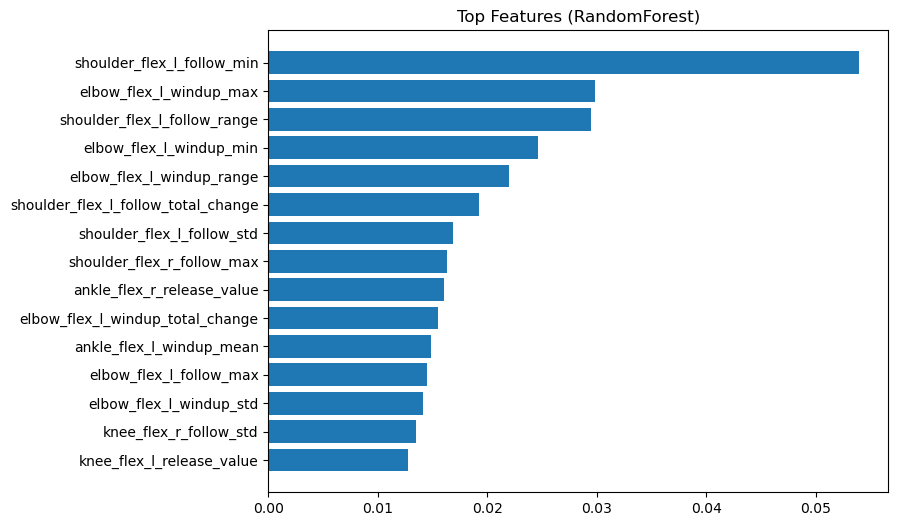

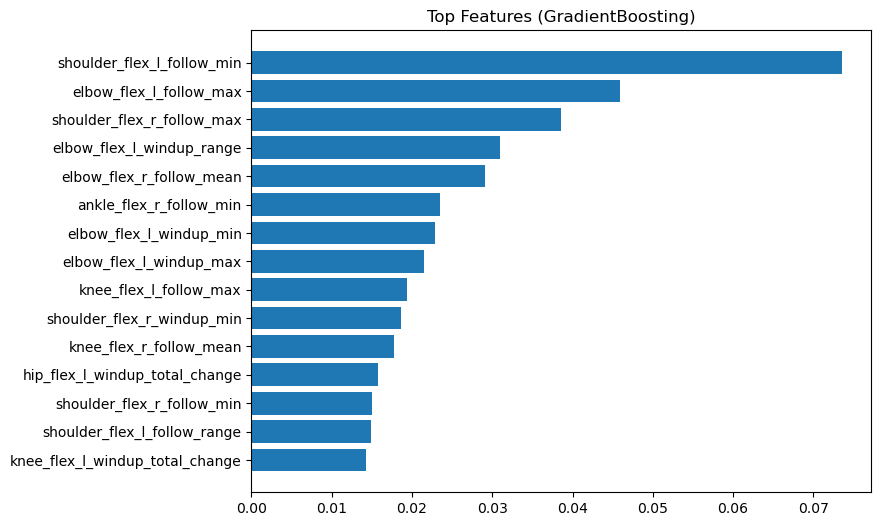

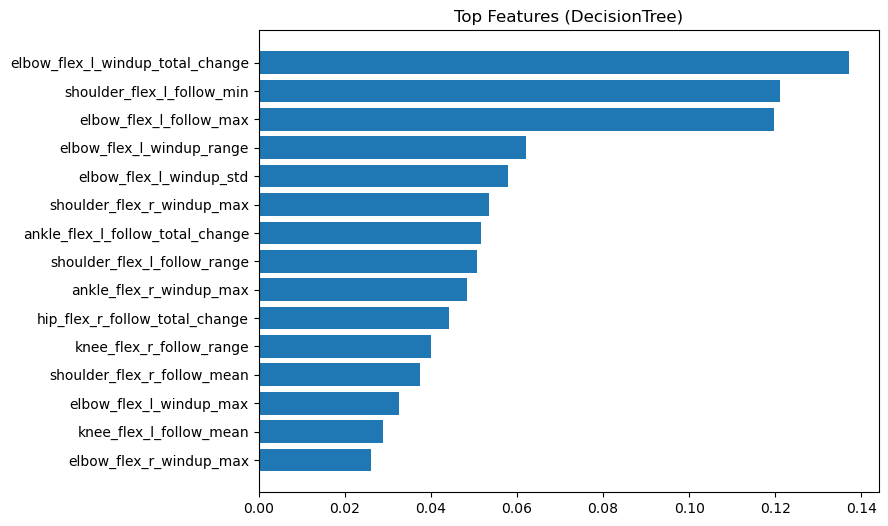

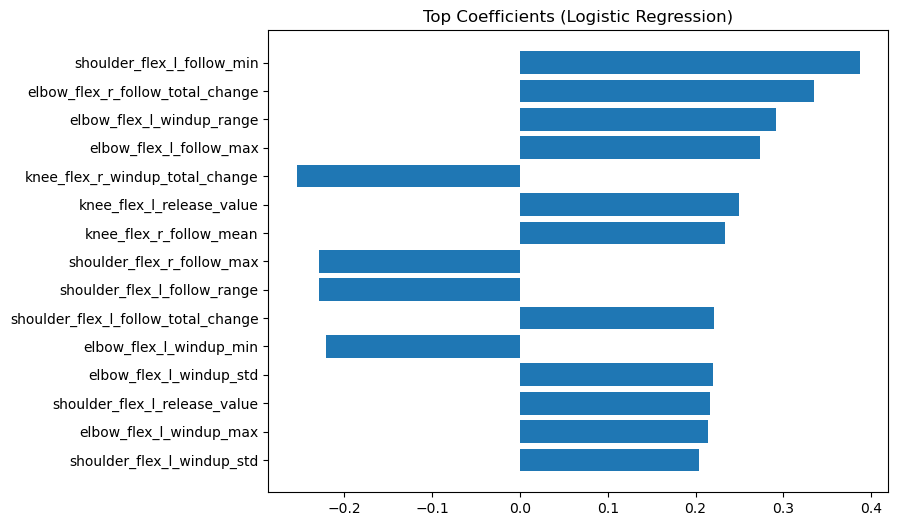

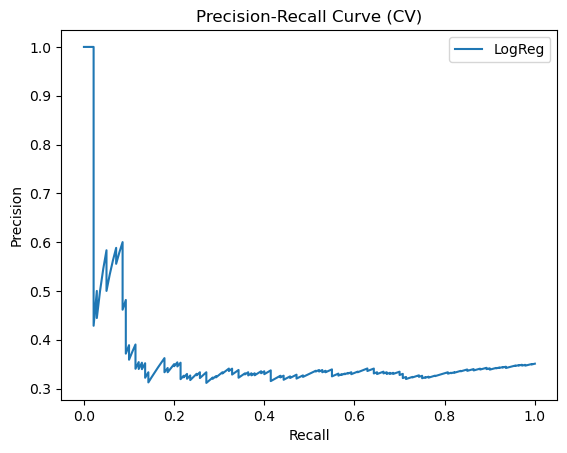

In [51]:
# =================================================
# B. During Model Building EDA
# =================================================
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# --- Feature importance (tree models) ---
for model_name in ["RandomForest", "GradientBoosting", "DecisionTree"]:
    if model_name in best_models:
        clf = best_models[model_name]["clf"] if "clf" in best_models[model_name].named_steps else best_models[model_name]
        if hasattr(clf, "feature_importances_"):
            importances = clf.feature_importances_
            idx = np.argsort(importances)[::-1][:15]  # top 15
            plt.figure(figsize=(8,6))
            plt.barh(range(len(idx)), importances[idx])
            plt.yticks(range(len(idx)), X_train.columns[idx])
            plt.title(f"Top Features ({model_name})")
            plt.gca().invert_yaxis()
            plt.show()

# --- Logistic Regression coefficients ---
if "LogisticRegression" in best_models:
    coef = best_models["LogisticRegression"].named_steps["clf"].coef_[0]
    idx = np.argsort(np.abs(coef))[::-1][:15]
    plt.figure(figsize=(8,6))
    plt.barh(range(len(idx)), coef[idx])
    plt.yticks(range(len(idx)), X_train.columns[idx])
    plt.title("Top Coefficients (Logistic Regression)")
    plt.gca().invert_yaxis()
    plt.show()

# --- Precision-Recall Curve (example: Logistic Regression) ---
if "LogisticRegression" in best_models:
    from sklearn.model_selection import cross_val_predict
    proba = cross_val_predict(best_models["LogisticRegression"], X_train, y_train, cv=5, method="predict_proba")[:,1]
    prec, rec, _ = precision_recall_curve(y_train, proba, pos_label=POS_LABEL)
    plt.plot(rec, prec, label="LogReg")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve (CV)")
    plt.legend()
    plt.show()


In [64]:
# =================================================
# Step 3: Calibration & Threshold Tuning
# =================================================
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score
)
import numpy as np
import pandas as pd
from scipy.special import expit  # for decision_function -> prob mapping

PRECISION_FLOOR = 0.70  # precision floor used by one of the strategies

# ---------------------------
# Split training into sub-train / validation
# ---------------------------
X_subtr, X_val, y_subtr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# ---------------------------
# Helpers (POS_LABEL-aware)
# ---------------------------
def pick_threshold(p, y, precision_floor=None, tmin=0.05, tmax=0.95, n=181, pos_label=POS_LABEL):
    """Grid-search a threshold on probabilities p to maximize F1 (optionally with a precision floor)."""
    ts = np.linspace(tmin, tmax, n)
    best = {"t": 0.5, "precision": 0.0, "recall": 0.0, "f1": -1.0}

    for t in ts:
        pred = (p >= t).astype(int)
        prec = precision_score(y, pred, pos_label=pos_label, zero_division=0)
        rec  = recall_score(y, pred,    pos_label=pos_label, zero_division=0)
        f1   = f1_score(y, pred,        pos_label=pos_label, zero_division=0)

        if precision_floor is None:
            if f1 > best["f1"]:
                best = {"t": float(t), "precision": prec, "recall": rec, "f1": f1}
        else:
            if (prec >= precision_floor) and (f1 > best["f1"]):
                best = {"t": float(t), "precision": prec, "recall": rec, "f1": f1}

    # fallback if precision_floor was too strict
    if precision_floor is not None and best["f1"] < 0:
        return pick_threshold(p, y, precision_floor=None, tmin=tmin, tmax=tmax, n=n, pos_label=pos_label)

    return best


def pos_proba(est, X, pos_label=POS_LABEL):
    """Return P(y==pos_label) for any fitted estimator/pipeline."""
    if hasattr(est, "predict_proba"):
        classes = list(est.classes_)
        idx = classes.index(pos_label)
        return est.predict_proba(X)[:, idx]

    if hasattr(est, "decision_function"):
        df = est.decision_function(X)
        classes = list(est.classes_)
        if df.ndim == 1:
            s = df if pos_label == classes[1] else -df
        else:
            s = df[:, classes.index(pos_label)]
        return expit(s)

    raise AttributeError("Estimator has neither predict_proba nor decision_function.")


# ---------------------------
# Calibration methods & strategies
# ---------------------------
calib_methods = ["none", "sigmoid", "isotonic"]  # added "none" for baseline
strategies = {
    "f1_max":    {"precision_floor": None},
    "f1_at_p70": {"precision_floor": PRECISION_FLOOR},
}

# ---------------------------
# Run calibration + thresholding
# ---------------------------
results = []

for model_name, base_model in best_models.items():
    for method in calib_methods:
        print(f"\n=== {model_name} | calibration={method} ===")

        if method == "none":
            # Use the base model directly (already tuned in step 2)
            model = base_model
            model.fit(X_subtr, y_subtr)
            p_val = pos_proba(model, X_val, pos_label=POS_LABEL)
        else:
            # Wrap with calibration
            model = CalibratedClassifierCV(base_model, cv=5, method=method)
            model.fit(X_subtr, y_subtr)
            p_val = pos_proba(model, X_val, pos_label=POS_LABEL)

        # Threshold strategies
        s1 = pick_threshold(p_val, y_val, **strategies["f1_max"])
        s2 = pick_threshold(p_val, y_val, **strategies["f1_at_p70"])

        # Threshold-free metrics
        ap  = average_precision_score(y_val, p_val, pos_label=POS_LABEL)
        roc = roc_auc_score(y_val, p_val)

        # Record both strategies
        results.append({
            "model": model_name,
            "calibration": method,
            "strategy": "f1_max",
            "best_threshold": s1["t"],
            "precision": s1["precision"],
            "recall": s1["recall"],
            "f1": s1["f1"],
            "AP": ap,
            "ROC_AUC": roc
        })
        results.append({
            "model": model_name,
            "calibration": method,
            "strategy": "f1_at_p70",
            "best_threshold": s2["t"],
            "precision": s2["precision"],
            "recall": s2["recall"],
            "f1": s2["f1"],
            "AP": ap,
            "ROC_AUC": roc
        })

# ---------------------------
# Summaries + persistence
# ---------------------------
calib_threshold_df = (
    pd.DataFrame(results)
    .sort_values(by=["model", "calibration", "strategy"])
    .reset_index(drop=True)
)

print("\n[CALIBRATION / THRESHOLD COMPARISON]")
display(calib_threshold_df)

summary = (
    calib_threshold_df
    .sort_values(["model", "f1"], ascending=[True, False])
    .groupby("model")
    .head(2)
    .reset_index(drop=True)
)

print("\n[TOP CHOICES PER MODEL]")
display(summary)

# Save CSVs
calib_threshold_df.to_csv(run_dir / "calibration_threshold_grid.csv", index=False)
summary.to_csv(run_dir / "calibration_threshold_summary.csv", index=False)
print(f"[INFO] Saved: {run_dir/'calibration_threshold_grid.csv'} and {run_dir/'calibration_threshold_summary.csv'}")



=== LogisticRegression | calibration=none ===

=== LogisticRegression | calibration=sigmoid ===

=== LogisticRegression | calibration=isotonic ===

=== KNN | calibration=none ===

=== KNN | calibration=sigmoid ===

=== KNN | calibration=isotonic ===

=== DecisionTree | calibration=none ===

=== DecisionTree | calibration=sigmoid ===

=== DecisionTree | calibration=isotonic ===

=== RandomForest | calibration=none ===

=== RandomForest | calibration=sigmoid ===

=== RandomForest | calibration=isotonic ===

=== GradientBoosting | calibration=none ===

=== GradientBoosting | calibration=sigmoid ===

=== GradientBoosting | calibration=isotonic ===

=== SVM | calibration=none ===

=== SVM | calibration=sigmoid ===

=== SVM | calibration=isotonic ===

=== LinearSVC | calibration=none ===

=== LinearSVC | calibration=sigmoid ===

=== LinearSVC | calibration=isotonic ===

[CALIBRATION / THRESHOLD COMPARISON]


,model,calibration,strategy,best_threshold,precision,recall,f1,AP,ROC_AUC
0,DecisionTree,isotonic,f1_at_p70,0.625,0.350000,1.000000,0.518519,0.462972,0.416209
1,DecisionTree,isotonic,f1_max,0.625,0.350000,1.000000,0.518519,0.462972,0.416209
2,DecisionTree,none,f1_at_p70,0.920,0.361111,0.928571,0.520000,0.375570,0.489011
3,DecisionTree,none,f1_max,0.920,0.361111,0.928571,0.520000,0.375570,0.489011
4,DecisionTree,sigmoid,f1_at_p70,0.295,0.750000,0.107143,0.187500,0.523868,0.407624
5,DecisionTree,sigmoid,f1_max,0.420,0.350000,1.000000,0.518519,0.523868,0.407624
6,GradientBoosting,isotonic,f1_at_p70,0.585,0.358974,1.000000,0.528302,0.380730,0.475618
7,GradientBoosting,isotonic,f1_max,0.585,0.358974,1.000000,0.528302,0.380730,0.475618
8,GradientBoosting,none,f1_at_p70,0.570,0.364865,0.964286,0.529412,0.390588,0.455357
9,GradientBoosting,none,f1_max,0.570,0.364865,0.964286,0.529412,0.390588,0.455357



[TOP CHOICES PER MODEL]


,model,calibration,strategy,best_threshold,precision,recall,f1,AP,ROC_AUC
0,DecisionTree,none,f1_at_p70,0.920,0.361111,0.928571,0.520000,0.375570,0.489011
1,DecisionTree,none,f1_max,0.920,0.361111,0.928571,0.520000,0.375570,0.489011
2,GradientBoosting,none,f1_at_p70,0.570,0.364865,0.964286,0.529412,0.390588,0.455357
3,GradientBoosting,none,f1_max,0.570,0.364865,0.964286,0.529412,0.390588,0.455357
4,KNN,sigmoid,f1_max,0.400,0.368421,1.000000,0.538462,0.411113,0.417926
5,KNN,isotonic,f1_at_p70,0.465,0.354430,1.000000,0.523364,0.429142,0.398352
6,LinearSVC,isotonic,f1_at_p70,0.505,0.364865,0.964286,0.529412,0.398574,0.432692
7,LinearSVC,isotonic,f1_max,0.505,0.364865,0.964286,0.529412,0.398574,0.432692
8,LogisticRegression,isotonic,f1_at_p70,0.630,0.358974,1.000000,0.528302,0.420457,0.394574
9,LogisticRegression,isotonic,f1_max,0.630,0.358974,1.000000,0.528302,0.420457,0.394574


[INFO] Saved: /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-27_12-21-56_run-001_baseline/calibration_threshold_grid.csv and /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-27_12-21-56_run-001_baseline/calibration_threshold_summary.csv


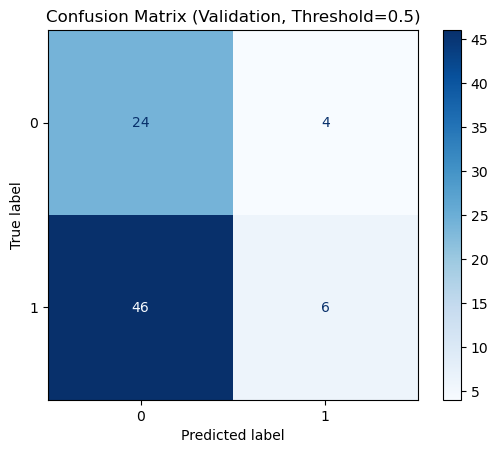

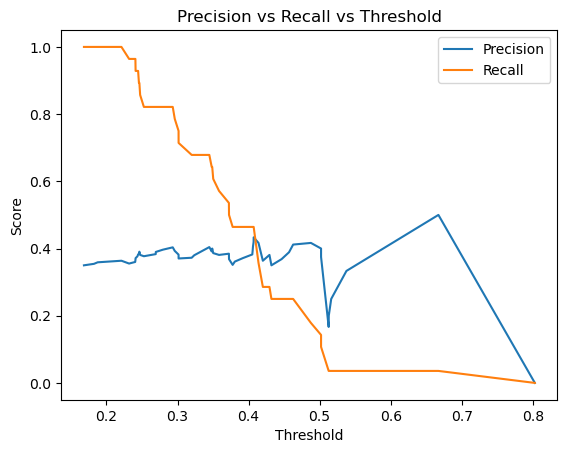

In [45]:
# =================================================
# C. After Thresholding & Calibration
# =================================================
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Example: visualize confusion matrix for best Logistic Regression
best_calib_model = cal  # last calibrated model (replace with your best choice)
p_val = pos_proba(best_calib_model, X_val, pos_label=POS_LABEL)
t = 0.5  # or use best threshold from summary
y_pred_val = (p_val >= t).astype(int)

cm = confusion_matrix(y_val, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Validation, Threshold=0.5)")
plt.show()

# Precision vs Recall curve
prec, rec, thr = precision_recall_curve(y_val, p_val, pos_label=POS_LABEL)
plt.plot(thr, prec[:-1], label="Precision")
plt.plot(thr, rec[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()
plt.show()


In [68]:
# =================================================
# Step 4: Full Training & Testing (Evaluation)
# =================================================
from joblib import dump
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    brier_score_loss, confusion_matrix
)
from sklearn.base import clone
from scipy.special import expit  # for decision_function→prob mapping

# Use the train already built; keep test untouched
X_train_full = X_train
y_train_full = y_train

final_dir = run_dir / "final_eval"
final_dir.mkdir(parents=True, exist_ok=True)
print(f"[INFO] Saving final model evaluations to {final_dir}")

# Models to evaluate
chosen_models = [
    "LogisticRegression",
    "KNN",
    "DecisionTree",
    "RandomForest",
    "GradientBoosting",
    "SVM",
    "LinearSVC",
]

# sanity checks
if 'best_models' not in globals():
    raise RuntimeError("best_models not found (run the hyperparameter tuning section first).")
if 'calib_threshold_df' not in globals():
    raise RuntimeError("calib_threshold_df not found (run the calibration/threshold section first).")

# --- POS_LABEL-aware probability helper (works with pipelines & margin models) ---
def pos_proba(clf, X, pos_label=POS_LABEL):
    # try predict_proba
    if hasattr(clf, "predict_proba"):
        classes = list(clf.classes_)
        idx = classes.index(pos_label)
        return clf.predict_proba(X)[:, idx]
    # fallback: decision_function → map to pos_label, then logistic squish
    if hasattr(clf, "decision_function"):
        df = clf.decision_function(X)
        classes = list(clf.classes_)
        if df.ndim == 1:
            s = df if pos_label == classes[1] else -df
        else:
            s = df[:, classes.index(pos_label)]
        return expit(s)
    raise AttributeError("Estimator has neither predict_proba nor decision_function.")

# Build: best calibration+threshold per model from calib_threshold_df
cfg_by_model = {}
for m in chosen_models:
    sub = calib_threshold_df[calib_threshold_df["model"] == m]
    if sub.empty:
        print(f"[WARN] No calibration rows for {m}; skipping.")
        continue
    # choose the row with highest F1 on your validation set
    row = sub.sort_values("f1", ascending=False).iloc[0]
    cfg_by_model[m] = {
        "calibration": row["calibration"],               # "none" | "sigmoid" | "isotonic"
        "threshold": float(row["best_threshold"]),
        "strategy": row["strategy"],
        "val_F1": float(row["f1"]),
        "val_precision": float(row["precision"]),
        "val_recall": float(row["recall"]),
        "val_AP": float(row["AP"]),
        "val_ROC_AUC": float(row["ROC_AUC"]),
    }

final_results = []
saved_paths = []

for m in chosen_models:
    if m not in cfg_by_model:
        continue
    if m not in best_models:
        print(f"[WARN] No tuned pipeline in best_models for {m}; skipping.")
        continue

    base   = best_models[m]
    method = cfg_by_model[m]["calibration"]
    thr    = cfg_by_model[m]["threshold"]

    print(f"\n=== {m}: train full (calibration={method}, thr={thr:.3f}) ===")

    # Fit the final estimator on ALL training data
    if method == "none":
        final_est = clone(base).fit(X_train_full, y_train_full)
    else:
        final_est = CalibratedClassifierCV(clone(base), cv=5, method=method)
        final_est.fit(X_train_full, y_train_full)

    # predict on test (POS_LABEL-aware)
    p_test = pos_proba(final_est, X_test, pos_label=POS_LABEL)
    y_hat  = (p_test >= thr).astype(int)

    # metrics (pass pos_label where applicable)
    prec = precision_score(y_test, y_hat, pos_label=POS_LABEL, zero_division=0)
    rec  = recall_score(y_test, y_hat,    pos_label=POS_LABEL, zero_division=0)
    f1   = f1_score(y_test, y_hat,        pos_label=POS_LABEL, zero_division=0)
    ap   = average_precision_score(y_test, p_test, pos_label=POS_LABEL)
    roc  = roc_auc_score(y_test, p_test)
    bri  = brier_score_loss(y_test, p_test)
    cm   = confusion_matrix(y_test, y_hat)

    print(f"[TEST] {m}  P={prec:.3f} R={rec:.3f} F1={f1:.3f} AP={ap:.3f} ROC={roc:.3f} Brier={bri:.3f}")
    print(pd.DataFrame(cm, index=["true 0","true 1"], columns=["pred 0","pred 1"]))

    # save model + plots
    tag = str(method).replace("/", "_")
    model_path = final_dir / f"{m}_cal-{tag}.joblib"
    dump(final_est, model_path)
    saved_paths.append(model_path.as_posix())

    try:
        fig_dir = final_dir / f"{m}_figs"
        save_all_eval_figures(
            outdir=fig_dir,
            y_true=y_test,
            y_pred=y_hat,
            y_proba=p_test,
            class_names=["Make (0)", "Miss (1)"]  # matches POS_LABEL convention
        )
    except NameError:
        pass

    final_results.append({
        "model": m,
        "calibration": method,
        "threshold": thr,
        "val_metrics": {
            "F1": cfg_by_model[m]["val_F1"],
            "precision": cfg_by_model[m]["val_precision"],
            "recall": cfg_by_model[m]["val_recall"],
            "AP": cfg_by_model[m]["val_AP"],
            "ROC_AUC": cfg_by_model[m]["val_ROC_AUC"],
            "strategy": cfg_by_model[m]["strategy"],
        },
        "test_metrics": {
            "F1": float(f1),
            "precision": float(prec),
            "recall": float(rec),
            "AP": float(ap),
            "ROC_AUC": float(roc),
            "Brier": float(bri),
            "confusion_matrix": cm.tolist(),
        }
    })

# save summary
if final_results:
    final_df = pd.DataFrame([{
        "model": r["model"],
        "calibration": r["calibration"],
        "threshold": r["threshold"],
        "val_F1": r["val_metrics"]["F1"],
        "test_F1": r["test_metrics"]["F1"],
        "test_precision": r["test_metrics"]["precision"],
        "test_recall": r["test_metrics"]["recall"],
        "test_AP": r["test_metrics"]["AP"],
        "test_ROC_AUC": r["test_metrics"]["ROC_AUC"],
        "test_Brier": r["test_metrics"]["Brier"],
    } for r in final_results]).sort_values("test_F1", ascending=False).reset_index(drop=True)

    display(final_df)
    (final_dir / "final_results.json").write_text(json.dumps(final_results, indent=2))
    final_df.to_csv(final_dir / "final_results.csv", index=False)
    print(f"\n[INFO] Saved models:\n  - " + "\n  - ".join(saved_paths))
    print(f"[INFO] Results:\n  - {final_dir/'final_results.json'}\n  - {final_dir/'final_results.csv'}")
else:
    print("[WARN] Nothing trained—check chosen_models & that Step 3 produced calib_threshold_df rows.")


[INFO] Saving final model evaluations to /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-27_12-21-56_run-001_baseline/final_eval

=== LogisticRegression: train full (calibration=isotonic, thr=0.630) ===
[TEST] LogisticRegression  P=0.360 R=0.973 F1=0.526 AP=0.525 ROC=0.359 Brier=0.351
        pred 0  pred 1
true 0      36       1
true 1      64       0


/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")



=== KNN: train full (calibration=sigmoid, thr=0.400) ===
[TEST] KNN  P=0.366 R=1.000 F1=0.536 AP=0.402 ROC=0.460 Brier=0.313
        pred 0  pred 1
true 0      37       0
true 1      64       0


/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")



=== DecisionTree: train full (calibration=none, thr=0.920) ===
[TEST] DecisionTree  P=0.367 R=0.892 F1=0.520 AP=0.400 ROC=0.446 Brier=0.435
        pred 0  pred 1
true 0      33       4
true 1      57       7


...

/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")



=== LinearSVC: train full (calibration=isotonic, thr=0.505) ===
[TEST] LinearSVC  P=0.347 R=0.892 F1=0.500 AP=0.496 ROC=0.423 Brier=0.344
        pred 0  pred 1
true 0      33       4
true 1      62       2


/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


,model,calibration,threshold,val_F1,test_F1,test_precision,test_recall,test_AP,test_ROC_AUC,test_Brier
0,KNN,sigmoid,0.400,0.538462,0.536232,0.366337,1.000000,0.401765,0.459882,0.312838
1,RandomForest,isotonic,0.545,0.523364,0.536232,0.366337,1.000000,0.495726,0.358319,0.341387
2,LogisticRegression,isotonic,0.630,0.528302,0.525547,0.360000,0.972973,0.524722,0.358742,0.350626
3,SVM,isotonic,0.545,0.524272,0.525547,0.360000,0.972973,0.558476,0.364654,0.341819
4,DecisionTree,none,0.920,0.520000,0.519685,0.366667,0.891892,0.400185,0.445735,0.435435
5,LinearSVC,isotonic,0.505,0.529412,0.500000,0.347368,0.891892,0.496290,0.422720,0.343735
6,GradientBoosting,none,0.570,0.529412,0.460317,0.325843,0.783784,0.569415,0.313767,0.393694



[INFO] Saved models:
  - /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-27_12-21-56_run-001_baseline/final_eval/LogisticRegression_cal-isotonic.joblib
  - /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-27_12-21-56_run-001_baseline/final_eval/KNN_cal-sigmoid.joblib
  - /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-27_12-21-56_run-001_baseline/final_eval/DecisionTree_cal-none.joblib
  - /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-27_12-21-56_run-001_baseline/final_eval/RandomForest_cal-isotonic.joblib
  - /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-27_12-21-56_run-001_baseline/final_eval/GradientBoosting_cal-none.joblib
  - /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-27_12-21-56_run-001_baseline/final_eval/SVM_cal-isotonic.joblib
  - /Users/kwill5

[Final Test Classification Report]
              precision    recall  f1-score   support

     Make(0)       0.35      0.89      0.50        37
     Miss(1)       0.43      0.05      0.08        64

    accuracy                           0.36       101
   macro avg       0.39      0.47      0.29       101
weighted avg       0.40      0.36      0.24       101



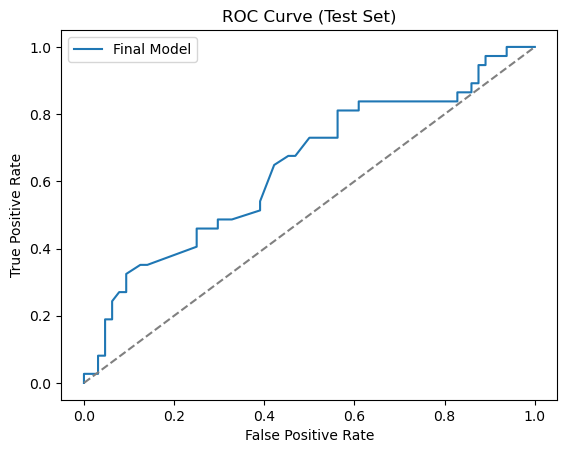

In [69]:
# =================================================
# D. Final Test Evaluation
# =================================================
from sklearn.metrics import classification_report

# Choose your top model (example: LogisticRegression with isotonic calib)
final_model = cal  # swap for your best
p_test = pos_proba(final_model, X_test, pos_label=POS_LABEL)
y_pred_test = (p_test >= 0.5).astype(int)

print("[Final Test Classification Report]")
print(classification_report(y_test, y_pred_test, target_names=["Make(0)", "Miss(1)"]))

# Final ROC curve
fpr, tpr, _ = roc_curve(y_test, p_test, pos_label=POS_LABEL)
plt.plot(fpr, tpr, label="Final Model")
plt.plot([0,1],[0,1],"--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set)")
plt.legend()
plt.show()


In [71]:
# ============================================================
# STEP 5: Diagnostics of final models 
# ============================================================
import json
import numpy as np
import pandas as pd
from pathlib import Path
from joblib import load
from scipy.special import expit  # keep at top-level for joblib pickling

from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    average_precision_score, roc_auc_score,
    brier_score_loss, confusion_matrix
)

# --------------------------
# Paths & inputs
# --------------------------
final_dir = run_dir / "final_eval"
results_json = final_dir / "final_results.json"
if not results_json.exists():
    raise FileNotFoundError(f"Expected {results_json} from Step 4 at: {results_json}")

with results_json.open() as f:
    final_results = json.load(f)

X_train_full = X_train
y_train_full = y_train

diag_root = run_dir / "diagnostics_final"
diag_root.mkdir(parents=True, exist_ok=True)

if 'X_val' in globals() and 'y_val' in globals():
    use_X_perm, use_y_perm, perm_where = X_val, y_val, "val"
else:
    use_X_perm, use_y_perm, perm_where = X_test, y_test, "test"
print(f"[INFO] Permutation importance will run on: {perm_where} set")

# --------------------------
# POS_LABEL-aware helpers
# --------------------------
# ---------- SAFE top-level logistic (no SciPy) ----------
def _expit(x):
    # stable sigmoid to avoid overflow in exp
    x = np.asarray(x, dtype=float)
    # clip to keep exp in a safe range
    x = np.clip(x, -35, 35)
    return 1.0 / (1.0 + np.exp(-x))

# ---------- POS_LABEL-aware proba helper (no SciPy) ----------
def pos_proba(est, X, pos_label=POS_LABEL):
    """
    Return P(y==pos_label) for any fitted estimator/pipeline.
    Uses predict_proba when available; otherwise maps decision_function
    through a stable logistic _expit.
    """
    if hasattr(est, "predict_proba"):
        classes = list(est.classes_)
        idx = classes.index(pos_label)
        return est.predict_proba(X)[:, idx]

    if hasattr(est, "decision_function"):
        df = est.decision_function(X)
        classes = list(est.classes_)
        if df.ndim == 1:
            s = df if pos_label == classes[1] else -df
        else:
            s = df[:, classes.index(pos_label)]
        return _expit(s)

    raise AttributeError("Estimator has neither predict_proba nor decision_function.")


# --------------------------
# Picklable scorers for permutation_importance
# --------------------------
def perm_score_roc_auc(est, X, y):
    p = pos_proba(est, X, pos_label=POS_LABEL)
    return roc_auc_score(y, p)

def perm_score_ap(est, X, y):
    p = pos_proba(est, X, pos_label=POS_LABEL)
    return average_precision_score(y, p, pos_label=POS_LABEL)

class ScorerF1AtThreshold:
    """Picklable callable for F1 at fixed threshold."""
    def __init__(self, threshold, pos_label):
        self.threshold = float(threshold)
        self.pos_label = pos_label
    def __call__(self, est, X, y):
        p = pos_proba(est, X, pos_label=self.pos_label)
        yhat = (p >= self.threshold).astype(int)
        return f1_score(y, yhat, pos_label=self.pos_label, zero_division=0)

# --------------------------
# Permutation-importance wrapper
# --------------------------
def _permutation_importance_df(
    estimator, X_perm, y_perm, feature_names,
    mode="roc_auc",      # "roc_auc" | "average_precision" | "f1_at_threshold"
    threshold=None,
    n_repeats=30,
    n_jobs=-1
):
    if mode == "roc_auc":
        scoring = perm_score_roc_auc
    elif mode == "average_precision":
        scoring = perm_score_ap
    elif mode == "f1_at_threshold":
        if threshold is None:
            raise ValueError("threshold must be provided for f1_at_threshold")
        scoring = ScorerF1AtThreshold(threshold=threshold, pos_label=POS_LABEL)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    res = permutation_importance(
        estimator, X_perm, y_perm,
        scoring=scoring, n_repeats=n_repeats,
        random_state=42, n_jobs=n_jobs
    )
    df = pd.DataFrame({
        "feature": feature_names,
        "perm_importance_mean": res.importances_mean,
        "perm_importance_std":  res.importances_std
    })
    return df.sort_values("perm_importance_mean", ascending=False).reset_index(drop=True)

# --------------------------
# Loop over final models
# --------------------------
summary_rows = []
feat_names = list(X_train_full.columns)

for entry in final_results:
    m        = entry["model"]
    method   = entry["calibration"]          # "none" | "sigmoid" | "isotonic"
    thr      = float(entry["threshold"])

    # mirror Step 4’s save naming
    tag = str(method).replace("/", "_")
    model_path = final_dir / f"{m}_cal-{tag}.joblib"

    if not model_path.exists():
        print(f"[WARN] Missing saved model for {m} at {model_path}; skipping.")
        continue

    print(f"\n=== {m} | load final model | calibration={method} | threshold={thr:.3f} ===")
    cal = load(model_path)  # final trained (possibly calibrated) model

    # --- Performance on TEST ---
    p_test = pos_proba(cal, X_test, pos_label=POS_LABEL)
    y_hat  = (p_test >= thr).astype(int)

    prec = precision_score(y_test, y_hat, pos_label=POS_LABEL, zero_division=0)
    rec  = recall_score(y_test, y_hat,    pos_label=POS_LABEL, zero_division=0)
    f1   = f1_score(y_test, y_hat,        pos_label=POS_LABEL, zero_division=0)
    ap   = average_precision_score(y_test, p_test, pos_label=POS_LABEL)
    roc  = roc_auc_score(y_test, p_test)
    bri  = brier_score_loss(y_test, p_test)
    cm   = confusion_matrix(y_test, y_hat, labels=[0, 1])

    print(f"[TEST] P={prec:.3f} R={rec:.3f} F1={f1:.3f} AP={ap:.3f} ROC={roc:.3f} Brier={bri:.3f}")

    # --- Save plots (if your util exists) ---
    outdir = (diag_root / m)
    figdir = outdir / "figs"
    outdir.mkdir(parents=True, exist_ok=True)
    try:
        save_all_eval_figures(figdir, y_test, y_hat, p_test, class_names=["Make (0)", "Miss (1)"])
    except NameError:
        pass

    # --- Save predictions & errors ---
    errs = X_test.copy()
    errs["y_true"] = y_test.values
    errs["y_prob"] = p_test
    errs["y_pred"] = y_hat
    errs["error_type"] = np.where(
        (errs["y_true"] == POS_LABEL) & (errs["y_pred"] != POS_LABEL), "FN",
        np.where((errs["y_true"] != POS_LABEL) & (errs["y_pred"] == POS_LABEL), "FP", "OK")
    )
    try:
        errs["session"] = session_test.values
    except Exception:
        pass
    errs.to_csv(outdir / "predictions_with_errors.csv", index=False)
    errs[errs["error_type"].isin(["FP","FN"])].to_csv(outdir / "misclassified_only.csv", index=False)

    # --- Permutation importances ---
    perm_auc = _permutation_importance_df(
        cal, use_X_perm, use_y_perm, feat_names,
        mode="roc_auc", n_repeats=30, n_jobs=-1
    )
    perm_auc.to_csv(outdir / f"importance_perm_rocauc_on_{perm_where}.csv", index=False)

    perm_f1thr = _permutation_importance_df(
        cal, use_X_perm, use_y_perm, feat_names,
        mode="f1_at_threshold", threshold=thr, n_repeats=30, n_jobs=-1
    )
    perm_f1thr.to_csv(outdir / f"importance_perm_f1_thr{thr:.3f}_on_{perm_where}.csv", index=False)

    # --- Config snapshot + summary row ---
    tn, fp, fn, tp = cm.ravel()
    meta = {
        "model": m,
        "calibration": method,
        "threshold": thr,
        "val_metrics_from_step4": entry.get("val_metrics", {}),
        "test_metrics": {
            "precision": float(prec),
            "recall": float(rec),
            "f1": float(f1),
            "AP": float(ap),
            "ROC_AUC": float(roc),
            "Brier": float(bri),
            "confusion_matrix": [int(tn), int(fp), int(fn), int(tp)]
        }
    }
    (outdir / "config_metrics.json").write_text(json.dumps(meta, indent=2))

    summary_rows.append({
        "model": m, "calibration": method, "threshold": thr,
        "precision": float(prec), "recall": float(rec), "f1": float(f1),
        "AP": float(ap), "ROC_AUC": float(roc), "Brier": float(bri),
        "perm_top_feature_rocauc": (perm_auc.iloc[0]["feature"] if len(perm_auc) else None),
        "perm_top_feature_f1thr": (perm_f1thr.iloc[0]["feature"] if len(perm_f1thr) else None),
    })

# --------------------------
# Roll-up table
# --------------------------
if summary_rows:
    summary_df = pd.DataFrame(summary_rows).sort_values("f1", ascending=False).reset_index(drop=True)
    display(summary_df)
    summary_df.to_csv(diag_root / "summary_across_models.csv", index=False)
    print(f"\n[INFO] Diagnostics written under: {diag_root}")
else:
    print("[WARN] No models diagnosed — check Step 4 outputs in", final_dir)


[INFO] Permutation importance will run on: val set

=== LogisticRegression | load final model | calibration=isotonic | threshold=0.630 ===
[TEST] P=0.360 R=0.973 F1=0.526 AP=0.525 ROC=0.359 Brier=0.351


/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")



=== KNN | load final model | calibration=sigmoid | threshold=0.400 ===
[TEST] P=0.366 R=1.000 F1=0.536 AP=0.402 ROC=0.460 Brier=0.313


/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")



=== DecisionTree | load final model | calibration=none | threshold=0.920 ===
[TEST] P=0.367 R=0.892 F1=0.520 AP=0.400 ROC=0.446 Brier=0.435


...

/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")



=== LinearSVC | load final model | calibration=isotonic | threshold=0.505 ===
[TEST] P=0.347 R=0.892 F1=0.500 AP=0.496 ROC=0.423 Brier=0.344


/opt/anaconda3/envs/RVL/lib/python3.12/site-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


,model,calibration,threshold,precision,recall,f1,AP,ROC_AUC,Brier,perm_top_feature_rocauc,perm_top_feature_f1thr
0,KNN,sigmoid,0.400,0.366337,1.000000,0.536232,0.401765,0.459882,0.312838,elbow_flex_r_follow_min,windup_duration
1,RandomForest,isotonic,0.545,0.366337,1.000000,0.536232,0.495726,0.358319,0.341387,knee_flex_l_windup_range,ankle_flex_l_windup_min
2,LogisticRegression,isotonic,0.630,0.360000,0.972973,0.525547,0.524722,0.358742,0.350626,ankle_flex_r_windup_max,hip_flex_r_follow_total_change
3,SVM,isotonic,0.545,0.360000,0.972973,0.525547,0.558476,0.364654,0.341819,elbow_flex_l_windup_max,shoulder_flex_r_follow_min
4,DecisionTree,none,0.920,0.366667,0.891892,0.519685,0.400185,0.445735,0.435435,ankle_flex_r_follow_min,windup_duration
5,LinearSVC,isotonic,0.505,0.347368,0.891892,0.500000,0.496290,0.422720,0.343735,knee_flex_l_follow_range,ankle_flex_r_windup_total_change
6,GradientBoosting,none,0.570,0.325843,0.783784,0.460317,0.569415,0.313767,0.393694,windup_duration,shoulder_flex_l_windup_std



[INFO] Diagnostics written under: /Users/kwill55/RVL/personalized-sports-optimization/experiments/summary_stats/2025-08-27_12-21-56_run-001_baseline/diagnostics_final


In [ ]:

# ===== Step 6: Feature Pruning from Permutation Importance =====

#sel_ang_and_static
EXPERIMENT = "2025-08-25_14-52-42_run-001_baseline" # <-- adjust path

# --- Config ---
EXPERIMENT_DIR = Path("../experiments") / MODEL_TYPE / EXPERIMENT 
IMPORTANCE_DIR = EXPERIMENT_DIR / "diagnostics_final"
OUTPUT_LIST    = EXPERIMENT_DIR / "reduced_features.csv"
OUTPUT_MERGED  = EXPERIMENT_DIR / "feature_importance_merged.csv"
THRESHOLD      = 0.01  # keep if mean_importance >= THRESHOLD after clipping negatives to 0

# Recursively find permutation importance CSVs under each model dir
files = list(IMPORTANCE_DIR.glob("**/importance_perm_*_on_val.csv"))
if not files:
    raise FileNotFoundError(f"No permutation CSVs found under {IMPORTANCE_DIR} (**/importance_perm_*_on_val.csv)")

# ---- Load all to long-form ----
rows = []
for f in files:
    # model name is the immediate parent directory (e.g., LinearSVC)
    model = f.parent.name
    # metric is everything between 'importance_perm_' and '_on_val'
    m = re.search(r"importance_perm_(.+)_on_val\.csv$", f.name)
    metric = m.group(1) if m else "unknown"

    df = pd.read_csv(f)  # expects: feature, perm_importance_mean, perm_importance_std
    if {"feature","perm_importance_mean","perm_importance_std"} - set(df.columns):
        raise ValueError(f"Unexpected columns in {f}: {df.columns.tolist()}")

    tmp = df[["feature","perm_importance_mean","perm_importance_std"]].copy()
    tmp["metric"] = metric
    tmp["model"]  = model
    rows.append(tmp)

long_df = pd.concat(rows, ignore_index=True)
long_df["perm_importance_mean"] = long_df["perm_importance_mean"].clip(lower=0)

# ---- Aggregate across models for each (feature, metric) ----
agg_df = (
    long_df
    .groupby(["feature","metric"], as_index=False)
    .agg(mean_over_models=("perm_importance_mean","mean"),
         std_over_models=("perm_importance_mean","std"))
)

# ---- Pivot to wide: one row per feature, columns = metrics (averaged over models) ----
wide = agg_df.pivot_table(index="feature", columns="metric", values="mean_over_models", aggfunc="first").fillna(0.0)
# flatten column index and prefix with 'mean_'
wide.columns = [f"mean_{c}" for c in wide.columns]
wide = wide.reset_index()

# ---- Overall mean importance across all metrics ----
mean_cols = [c for c in wide.columns if c.startswith("mean_")]
wide["mean_importance"] = wide[mean_cols].mean(axis=1)

# ---- Filter by threshold and save ----
reduced = wide[wide["mean_importance"] >= THRESHOLD].sort_values("mean_importance", ascending=False)
reduced["feature"].to_csv(OUTPUT_LIST, index=False)
wide.sort_values("mean_importance", ascending=False).to_csv(OUTPUT_MERGED, index=False)

print(f"[INFO] Files loaded: {len(files)}")
print(f"[INFO] Features kept: {len(reduced)} / {len(wide)} (threshold={THRESHOLD})")
print(f"[INFO] Saved reduced list -> {OUTPUT_LIST}")
print(f"[INFO] Saved merged table -> {OUTPUT_MERGED}")

[INFO] Files loaded: 14
[INFO] Features kept: 0 / 3 (threshold=0.01)
[INFO] Saved reduced list -> ../experiments/summary_stats/2025-08-26_14-05-56_run-001_all_angles_all_stats/reduced_features.csv
[INFO] Saved merged table -> ../experiments/summary_stats/2025-08-26_14-05-56_run-001_all_angles_all_stats/feature_importance_merged.csv
